=== 🎵 ADVANCED AUDIO CLASSIFICATION (DNN + CNN) - ROBUST FIXED SHAPES ===
🎵 COLLECTING DEEP DATASET
Classes: ['audioanjing', 'audiobabi', 'audiobajingan', 'audiobangsat', 'audiogoblok', 'audiojancuk', 'audiotai', 'audiotolol']

📂 Processing: audioanjing
   Found 25 files
   [1/20] anjing1.wav
   [2/20] anjing13.wav
   [3/20] anjing14.wav
   [4/20] anjing15.wav
   [5/20] anjing19.wav
   [6/20] anjing20.wav
   [7/20] anjing21.wav
   [8/20] anjing23.wav
   [9/20] anjing24.wav
   [10/20] anjing25.wav
   [11/20] anjing29.wav
   [12/20] anjing3.wav
   [13/20] anjing34.wav
   [14/20] anjing36.wav
   [15/20] anjing37.wav
   [16/20] anjing39.wav
   [17/20] anjing44.wav
   [18/20] anjing5.wav
   [19/20] anjing52.wav
   [20/20] anjing53.wav
   🎯 Completed: 20/20

📂 Processing: audiobabi
   Found 24 files
   [1/20] babi101.wav
   [2/20] babi11.wav
   [3/20] babi2.wav
   [4/20] babi20.wav
   [5/20] babi25.wav
   [6/20] babi3.wav
   [7/20] babi34.wav
   [8/20] babi36.wav
   [9/20] babi39.wav
   [10/

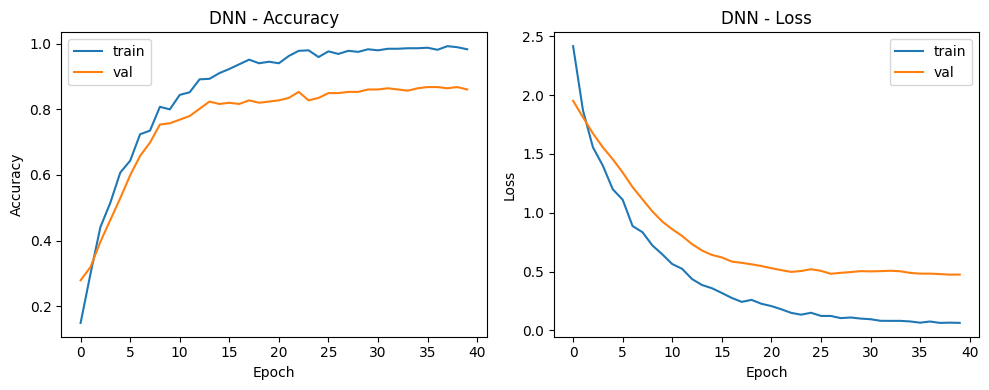


🔧 Training CNN (spectrograms)...
Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.2766 - loss: 2.3753
Epoch 1: val_accuracy improved from None to 0.20956, saving model to best_cnn_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.3454 - loss: 2.0234 - val_accuracy: 0.2096 - val_loss: 2.0475 - learning_rate: 0.0010
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7421 - loss: 0.8621
Epoch 2: val_accuracy did not improve from 0.20956
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.7681 - loss: 0.7759 - val_accuracy: 0.1324 - val_loss: 2.1305 - learning_rate: 0.0010
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9108 - loss: 0.3618
Epoch 3: val_accuracy did not improve from 0.20956
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.9180 - loss: 0.3315 - val_accuracy: 0.1324 - val_loss: 2.3121 - learning_rate: 0.0010
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9761 - loss: 0.1676
Epoch 4

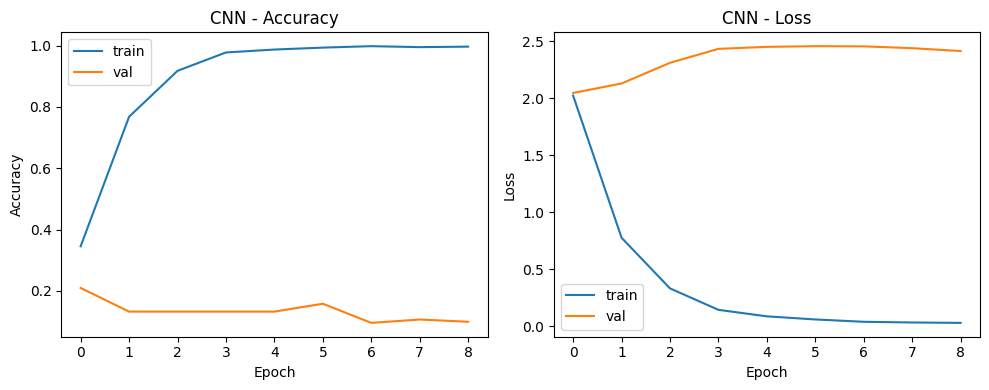


🎯 DNN Accuracy: 0.8676

📈 Classification report:
               precision    recall  f1-score   support

  audioanjing     0.9375    0.8333    0.8824        36
    audiobabi     0.8611    0.8611    0.8611        36
audiobajingan     0.9444    0.9444    0.9444        36
 audiobangsat     0.8235    0.7778    0.8000        36
  audiogoblok     0.7805    0.8889    0.8312        36
  audiojancuk     0.8684    0.9167    0.8919        36
     audiotai     0.6818    0.7500    0.7143        20
   audiotolol     1.0000    0.9167    0.9565        36

     accuracy                         0.8676       272
    macro avg     0.8622    0.8611    0.8602       272
 weighted avg     0.8728    0.8676    0.8688       272



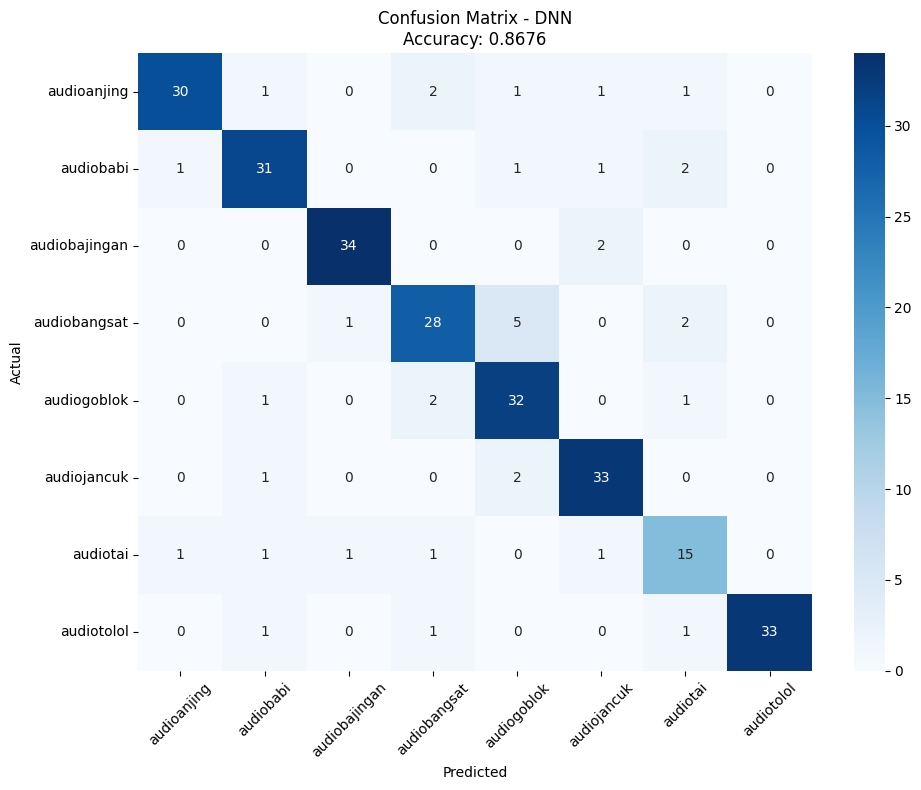


🎯 CNN Accuracy: 0.2096

📈 Classification report:
               precision    recall  f1-score   support

  audioanjing     0.0000    0.0000    0.0000        36
    audiobabi     0.0000    0.0000    0.0000        36
audiobajingan     0.1925    1.0000    0.3229        36
 audiobangsat     0.0000    0.0000    0.0000        36
  audiogoblok     0.0000    0.0000    0.0000        36
  audiojancuk     0.0000    0.0000    0.0000        36
     audiotai     0.0000    0.0000    0.0000        20
   audiotolol     0.2471    0.5833    0.3471        36

     accuracy                         0.2096       272
    macro avg     0.0549    0.1979    0.0837       272
 weighted avg     0.0582    0.2096    0.0887       272



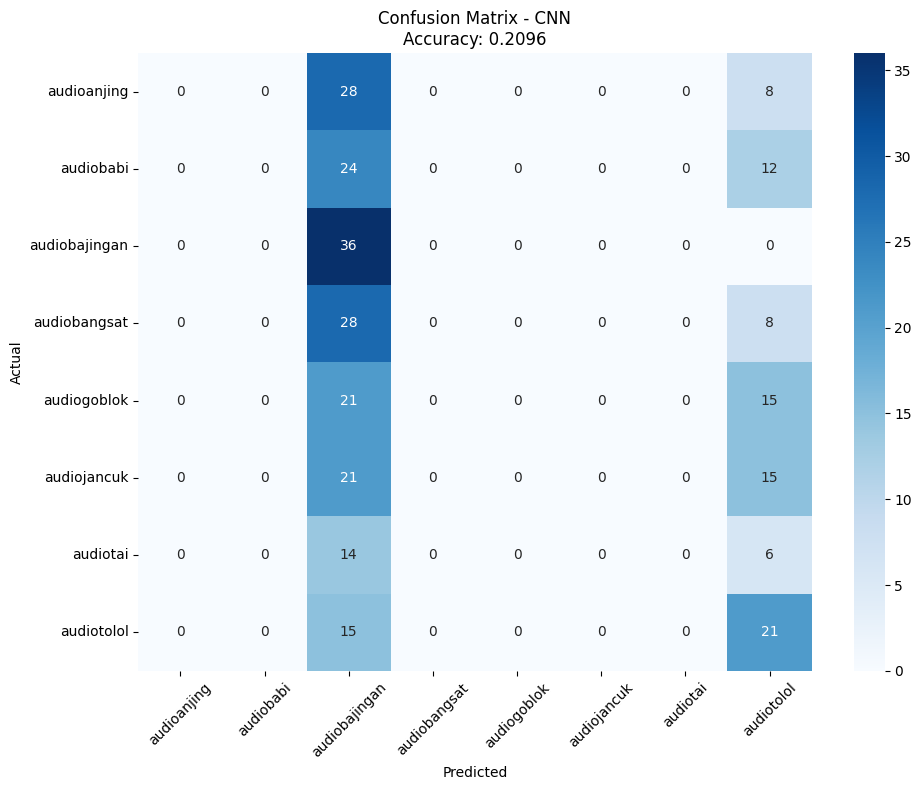


💾 Saving models and scalers...
✅ Saved: advanced_dnn_audio_model.keras, advanced_cnn_audio_model.keras, audio_scaler_and_labels.pkl

🎉 FINAL ANALYSIS
✅ OUTSTANDING! Accuracy: 0.8676
   Model is production-ready! 🚀

📊 Details:
   Best Model: DNN
   Total Samples: 906
   Vector Feature Length: 183 (expected 183)
   Spectrogram Shape: (64, 87, 1) (expected 64 x 87 x 1)
   Classes: 8


In [1]:
# =========================
# ADVANCED AUDIO CLASSIFICATION - DEEP LEARNING (DNN + CNN) - ROBUST FIXED SHAPES
# =========================
import os
import numpy as np
import librosa
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Activation
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ---------- Konfigurasi ----------
DATA_DIR = r"D:\web\cnn_clasification\archive\Data\genres_original"  # Ganti sesuai dataset kamu
SR = 22050
DURATION = 2.0
SEED = 42
AUGMENT = True
SAMPLES_PER_CLASS = 20

# Target ukuran tetap
N_MELS = 64
SPEC_TIME_FRAMES = 87         # target jumlah frame waktu untuk spectrogram (≈ 2s @ hop=512)
TARGET_VECTOR_DIM = 183       # target panjang vektor fitur

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------- Helpers ----------
def flatten_numeric(x):
    """Paksa output menjadi list angka float32 (flatten), menghindari 'sequence inside element'."""
    arr = np.asarray(x, dtype=np.float32)
    if arr.ndim == 0:
        return [float(arr)]
    return arr.reshape(-1).tolist()

def pad_or_trim(y, sr, duration):
    target_length = int(sr * duration)
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode='constant')
    else:
        y = y[:target_length]
    return y

def safe_trim(y, sr, duration, top_db=25):
    # Trim silence lalu pad/trim ke fixed length
    try:
        y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)
        if len(y_trimmed) > 0:
            y = y_trimmed
    except Exception:
        pass
    y = pad_or_trim(y, sr, duration)
    return y

def augment_audio(y, sr):
    augmented = []
    # Tambah noise ringan
    noise = 0.005 * np.random.randn(len(y))
    augmented.append(y + noise)
    # Pitch shift +2
    try:
        augmented.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=2))
    except Exception:
        pass
    # Pitch shift -2
    try:
        augmented.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=-2))
    except Exception:
        pass
    # Time-stretch 0.9
    try:
        augmented.append(librosa.effects.time_stretch(y, rate=0.9))
    except Exception:
        pass
    # Time-stretch 1.1
    try:
        augmented.append(librosa.effects.time_stretch(y, rate=1.1))
    except Exception:
        pass
    # Pastikan setiap hasil di-pad/trim ulang agar fix length
    augmented = [pad_or_trim(a, sr, DURATION) for a in augmented]
    return augmented

# ---------- Fixed feature extraction (vector) ----------
def extract_fixed_vector_features(audio_path, sr=SR, duration=DURATION, target_dim=TARGET_VECTOR_DIM):
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=duration, mono=True)
        y = safe_trim(y, sr, duration)

        feats = []

        # MFCC stats
        mfcc13 = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc20 = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        feats += flatten_numeric(np.mean(mfcc13, axis=1))
        feats += flatten_numeric(np.std(mfcc13, axis=1))
        feats += flatten_numeric(np.mean(mfcc20, axis=1))
        feats += flatten_numeric(np.std(mfcc20, axis=1))

        # Delta MFCC
        mfcc_delta = librosa.feature.delta(mfcc13)
        mfcc_delta2 = librosa.feature.delta(mfcc13, order=2)
        feats += flatten_numeric(np.mean(mfcc_delta, axis=1))
        feats += flatten_numeric(np.std(mfcc_delta, axis=1))
        feats += flatten_numeric(np.mean(mfcc_delta2, axis=1))
        feats += flatten_numeric(np.std(mfcc_delta2, axis=1))

        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        feats += flatten_numeric(np.mean(spectral_centroid))
        feats += flatten_numeric(np.std(spectral_centroid))
        feats += flatten_numeric(np.mean(spectral_rolloff))
        feats += flatten_numeric(np.std(spectral_rolloff))
        feats += flatten_numeric(np.mean(spectral_bandwidth))
        feats += flatten_numeric(np.std(spectral_bandwidth))

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        feats += flatten_numeric(np.mean(chroma, axis=1))
        feats += flatten_numeric(np.std(chroma, axis=1))

        # Spectral contrast
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        feats += flatten_numeric(np.mean(contrast, axis=1))
        feats += flatten_numeric(np.std(contrast, axis=1))

        # Tonnetz (bisa gagal bila tidak cukup harmonic content)
        try:
            tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
            feats += flatten_numeric(np.mean(tonnetz, axis=1))
            feats += flatten_numeric(np.std(tonnetz, axis=1))
        except Exception:
            feats += [0.0] * 6  # mean tonnetz
            feats += [0.0] * 6  # std tonnetz

        # Rhythm
        try:
            tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        except Exception:
            tempo = 0.0
        feats += [float(tempo)]

        # ZCR
        zcr = librosa.feature.zero_crossing_rate(y)
        feats += flatten_numeric(np.mean(zcr))
        feats += flatten_numeric(np.std(zcr))

        # RMS
        rms = librosa.feature.rms(y=y)
        feats += flatten_numeric(np.mean(rms))
        feats += flatten_numeric(np.std(rms))

        # Mel stats
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
        mel_db = librosa.power_to_db(mel)
        feats += flatten_numeric(np.mean(mel_db))
        feats += flatten_numeric(np.std(mel_db))
        feats += flatten_numeric(np.max(mel_db))
        feats += flatten_numeric(np.min(mel_db))

        features_array = np.array(feats, dtype=np.float32)
        features_array = np.nan_to_num(features_array)

        # Pastikan panjang konsisten
        if len(features_array) < target_dim:
            features_array = np.pad(features_array, (0, target_dim - len(features_array)), mode='constant')
        elif len(features_array) > target_dim:
            features_array = features_array[:target_dim]

        return features_array
    except Exception as e:
        print(f"❌ {Path(audio_path).name}: {e}")
        return None

# Versi dari waveform (untuk augmentasi)
def extract_vector_from_waveform(y, sr=SR, target_dim=TARGET_VECTOR_DIM):
    try:
        y = safe_trim(y, sr, DURATION)
        feats = []

        mfcc13 = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc20 = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        feats += flatten_numeric(np.mean(mfcc13, axis=1))
        feats += flatten_numeric(np.std(mfcc13, axis=1))
        feats += flatten_numeric(np.mean(mfcc20, axis=1))
        feats += flatten_numeric(np.std(mfcc20, axis=1))

        mfcc_delta = librosa.feature.delta(mfcc13)
        mfcc_delta2 = librosa.feature.delta(mfcc13, order=2)
        feats += flatten_numeric(np.mean(mfcc_delta, axis=1))
        feats += flatten_numeric(np.std(mfcc_delta, axis=1))
        feats += flatten_numeric(np.mean(mfcc_delta2, axis=1))
        feats += flatten_numeric(np.std(mfcc_delta2, axis=1))

        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        feats += flatten_numeric(np.mean(spectral_centroid))
        feats += flatten_numeric(np.std(spectral_centroid))
        feats += flatten_numeric(np.mean(spectral_rolloff))
        feats += flatten_numeric(np.std(spectral_rolloff))
        feats += flatten_numeric(np.mean(spectral_bandwidth))
        feats += flatten_numeric(np.std(spectral_bandwidth))

        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        feats += flatten_numeric(np.mean(chroma, axis=1))
        feats += flatten_numeric(np.std(chroma, axis=1))

        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        feats += flatten_numeric(np.mean(contrast, axis=1))
        feats += flatten_numeric(np.std(contrast, axis=1))

        try:
            tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
            feats += flatten_numeric(np.mean(tonnetz, axis=1))
            feats += flatten_numeric(np.std(tonnetz, axis=1))
        except Exception:
            feats += [0.0] * 6
            feats += [0.0] * 6

        try:
            tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        except Exception:
            tempo = 0.0
        feats += [float(tempo)]

        zcr = librosa.feature.zero_crossing_rate(y)
        feats += flatten_numeric(np.mean(zcr))
        feats += flatten_numeric(np.std(zcr))

        rms = librosa.feature.rms(y=y)
        feats += flatten_numeric(np.mean(rms))
        feats += flatten_numeric(np.std(rms))

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
        mel_db = librosa.power_to_db(mel)
        feats += flatten_numeric(np.mean(mel_db))
        feats += flatten_numeric(np.std(mel_db))
        feats += flatten_numeric(np.max(mel_db))
        feats += flatten_numeric(np.min(mel_db))

        features_array = np.array(feats, dtype=np.float32)
        features_array = np.nan_to_num(features_array)

        if len(features_array) < target_dim:
            features_array = np.pad(features_array, (0, target_dim - len(features_array)), mode='constant')
        elif len(features_array) > target_dim:
            features_array = features_array[:target_dim]

        return features_array
    except Exception as e:
        print(f"❌ waveform: {e}")
        return None

# ---------- Fixed spectrogram extraction (image for CNN) ----------
def extract_fixed_spectrogram(audio_path, sr=SR, duration=DURATION, n_mels=N_MELS, target_frames=SPEC_TIME_FRAMES):
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=duration, mono=True)
        y = safe_trim(y, sr, duration)

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

        # Pad/truncate ke jumlah frame waktu tetap
        T = mel_db.shape[1]
        if T < target_frames:
            pad_width = target_frames - T
            mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant')
        elif T > target_frames:
            mel_db = mel_db[:, :target_frames]

        mel_db = np.nan_to_num(mel_db)
        return mel_db.astype(np.float32)
    except Exception as e:
        print(f"❌ {Path(audio_path).name}: {e}")
        return None

# Versi dari waveform (untuk augmentasi)
def extract_spectrogram_from_waveform(y, sr=SR, n_mels=N_MELS, target_frames=SPEC_TIME_FRAMES):
    try:
        y = safe_trim(y, sr, DURATION)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

        T = mel_db.shape[1]
        if T < target_frames:
            pad_width = target_frames - T
            mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant')
        elif T > target_frames:
            mel_db = mel_db[:, :target_frames]

        mel_db = np.nan_to_num(mel_db)
        return mel_db.astype(np.float32)
    except Exception as e:
        print(f"❌ waveform: {e}")
        return None

# ---------- Dataset collection with augmentation ----------
def collect_deep_dataset(data_dir, samples_per_class=SAMPLES_PER_CLASS, augment=AUGMENT):
    data_root = Path(data_dir)
    class_dirs = [d for d in data_root.iterdir() if d.is_dir()]
    class_dirs.sort()
    class_names = [d.name for d in class_dirs]

    print("🎵 COLLECTING DEEP DATASET")
    print(f"Classes: {class_names}")
    print("=" * 50)

    X_vec, X_spec, y = [], [], []

    for class_idx, class_dir in enumerate(class_dirs):
        print(f"\n📂 Processing: {class_names[class_idx]}")
        audio_files = []
        for ext in [".wav", ".mp3", ".au"]:
            audio_files.extend(list(class_dir.glob(f"*{ext}")))
        print(f"   Found {len(audio_files)} files")

        if len(audio_files) > samples_per_class:
            audio_files = audio_files[:samples_per_class]

        processed = 0
        for i, audio_file in enumerate(audio_files):
            print(f"   [{i+1}/{len(audio_files)}] {audio_file.name}")
            vec = extract_fixed_vector_features(str(audio_file), target_dim=TARGET_VECTOR_DIM)
            spec = extract_fixed_spectrogram(str(audio_file), n_mels=N_MELS, target_frames=SPEC_TIME_FRAMES)

            if vec is not None and spec is not None:
                X_vec.append(vec)
                X_spec.append(spec)
                y.append(class_idx)
                processed += 1

                # Augmentasi dengan konsistensi bentuk
                if augment:
                    try:
                        y_raw, sr = librosa.load(str(audio_file), sr=SR, duration=DURATION, mono=True)
                        y_raw = safe_trim(y_raw, sr, DURATION)
                        aug_list = augment_audio(y_raw, SR)
                        for aug_y in aug_list:
                            vec_aug = extract_vector_from_waveform(aug_y, sr=SR, target_dim=TARGET_VECTOR_DIM)
                            spec_aug = extract_spectrogram_from_waveform(aug_y, sr=SR, n_mels=N_MELS, target_frames=SPEC_TIME_FRAMES)
                            if vec_aug is not None and spec_aug is not None:
                                X_vec.append(vec_aug)
                                X_spec.append(spec_aug)
                                y.append(class_idx)
                    except Exception as e:
                        print(f"   ⚠️ Augmentation failed: {e}")

        print(f"   🎯 Completed: {processed}/{len(audio_files)}")

    if len(X_vec) == 0 or len(X_spec) == 0:
        raise RuntimeError("No data extracted. Please check DATA_DIR and audio files.")

    X_vec = np.array(X_vec, dtype=np.float32)
    X_spec = np.array(X_spec, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    print(f"\n📊 DEEP DATASET CREATED!")
    print(f"   Total samples: {X_vec.shape[0]}")
    print(f"   Vector feature length: {X_vec.shape[1]} (expected {TARGET_VECTOR_DIM})")
    print(f"   Spectrogram shape: {X_spec.shape[1:]} (expected {N_MELS} x {SPEC_TIME_FRAMES})")
    print(f"   Classes: {len(class_names)}")

    return X_vec, X_spec, y, class_names

# ---------- Build DNN for vector features ----------
def build_dnn(input_dim, num_classes):
    model = Sequential([
        Dense(512, input_dim=input_dim),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.35),

        Dense(256),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.35),

        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.35),

        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ---------- Build CNN for spectrograms ----------
def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(256),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ---------- Training helpers ----------
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
        ModelCheckpoint(f'{model_name}.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
    ]

def plot_history(history, title='Training history'):
    plt.figure(figsize=(10,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    plt.show()

def evaluate_and_report(model, X_test, y_test, class_names, title='Model'):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n🎯 {title} Accuracy: {acc:.4f}")
    print("\n📈 Classification report:")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {title}\nAccuracy: {acc:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    return acc

# ---------- MAIN EXECUTION ----------
def main():
    print("=== 🎵 ADVANCED AUDIO CLASSIFICATION (DNN + CNN) - ROBUST FIXED SHAPES ===")
    print("=" * 60)

    try:
        # Step 1: Collect dataset (vector + spectrogram)
        X_vec, X_spec, y, class_names = collect_deep_dataset(DATA_DIR, samples_per_class=SAMPLES_PER_CLASS, augment=AUGMENT)

        # Step 2: Train/test split
        # DNN
        Xv_train, Xv_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=SEED, stratify=y)

        scaler = StandardScaler()
        Xv_train_scaled = scaler.fit_transform(Xv_train)
        Xv_test_scaled = scaler.transform(Xv_test)

        # CNN
        X_spec = X_spec[..., np.newaxis]  # add channel dimension
        Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_spec, y, test_size=0.3, random_state=SEED, stratify=y)

        print(f"\n📈 Data Split:")
        print(f"   DNN - Train: {Xv_train.shape[0]} | Test: {Xv_test.shape[0]} | Features: {Xv_train.shape[1]}")
        print(f"   CNN - Train: {Xs_train.shape[0]} | Test: {Xs_test.shape[0]} | Spec shape: {Xs_train.shape[1:]}")

        # Step 3: Build models
        dnn = build_dnn(input_dim=Xv_train_scaled.shape[1], num_classes=len(class_names))
        cnn = build_cnn(input_shape=Xs_train.shape[1:], num_classes=len(class_names))

        # Step 4: Train models
        print("\n🔧 Training DNN (vector features)...")
        dnn_hist = dnn.fit(
            Xv_train_scaled, y_train,
            validation_data=(Xv_test_scaled, y_test),
            epochs=40, batch_size=64,
            callbacks=get_callbacks('best_dnn_model'),
            verbose=1
        )
        plot_history(dnn_hist, title='DNN')

        print("\n🔧 Training CNN (spectrograms)...")
        cnn_hist = cnn.fit(
            Xs_train, ys_train,
            validation_data=(Xs_test, ys_test),
            epochs=40, batch_size=32,
            callbacks=get_callbacks('best_cnn_model'),
            verbose=1
        )
        plot_history(cnn_hist, title='CNN')

        # Step 5: Evaluation
        dnn_acc = evaluate_and_report(dnn, Xv_test_scaled, y_test, class_names, title='DNN')
        cnn_acc = evaluate_and_report(cnn, Xs_test, ys_test, class_names, title='CNN')

        # Step 6: Save artifacts
        print("\n💾 Saving models and scalers...")
        dnn.save('advanced_dnn_audio_model.keras')
        cnn.save('advanced_cnn_audio_model.keras')
        joblib.dump({'scaler': scaler, 'class_names': class_names}, 'audio_scaler_and_labels.pkl')
        print("✅ Saved: advanced_dnn_audio_model.keras, advanced_cnn_audio_model.keras, audio_scaler_and_labels.pkl")

        # Final analysis
        print("\n" + "=" * 60)
        print("🎉 FINAL ANALYSIS")
        print("=" * 60)
        best_acc = max(dnn_acc, cnn_acc if cnn_acc is not None else 0)
        best_model = 'CNN' if cnn_acc >= dnn_acc else 'DNN'
        if best_acc > 0.8:
            print(f"✅ OUTSTANDING! Accuracy: {best_acc:.4f}")
            print("   Model is production-ready! 🚀")
        elif best_acc > 0.6:
            print(f"✅ VERY GOOD! Accuracy: {best_acc:.4f}")
            print("   Model is working well! 👍")
        elif best_acc > 0.4:
            print(f"⚠️  MODERATE: Accuracy: {best_acc:.4f}")
            print("   Consider more data or feature engineering")
        elif best_acc > 0.2:
            print(f"🔶 NEEDS WORK: Accuracy: {best_acc:.4f}")
            print("   The task might be very challenging")
        else:
            print(f"❌ POOR: Accuracy: {best_acc:.4f}")
            print("   Fundamental issue with the approach")

        print(f"\n📊 Details:")
        print(f"   Best Model: {best_model}")
        print(f"   Total Samples: {X_vec.shape[0]}")
        print(f"   Vector Feature Length: {X_vec.shape[1]} (expected {TARGET_VECTOR_DIM})")
        print(f"   Spectrogram Shape: {X_spec.shape[1:]} (expected {N_MELS} x {SPEC_TIME_FRAMES} x 1)")
        print(f"   Classes: {len(class_names)}")

        return best_acc

    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        import traceback
        traceback.print_exc()
        return 0

if __name__ == "__main__":
    accuracy = main()
